In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import networkx as nx

# Part A: Data Preparation
print("="*60)
print("MARKET BASKET ANALYSIS")
print("="*60)

# Sample transaction data
transactions = [
    ['Bread', 'Milk', 'Eggs'],
    ['Bread', 'Butter', 'Jam'],
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Milk', 'Butter', 'Eggs'],
    ['Milk', 'Eggs', 'Cereal'],
    ['Bread', 'Eggs', 'Milk'],
    ['Butter', 'Jam', 'Bread'],
    ['Bread', 'Milk', 'Butter'],
    ['Milk', 'Cereal', 'Eggs'],
    ['Bread', 'Butter', 'Jam', 'Milk']
]

print(f"\nTotal transactions: {len(transactions)}")
print("\nSample transactions:")
for i in range(3):
    print(f"Transaction {i+1}: {transactions[i]}")

# Create binary matrix
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

print("\nBinary matrix (first 5 rows):")
print(df.head())

# Basic statistics
print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)

# Item frequencies
item_freq = df.sum().sort_values(ascending=False)
print("\nItem frequencies:")


MARKET BASKET ANALYSIS

Total transactions: 10

Sample transactions:
Transaction 1: ['Bread', 'Milk', 'Eggs']
Transaction 2: ['Bread', 'Butter', 'Jam']
Transaction 3: ['Milk', 'Bread', 'Butter']

Binary matrix (first 5 rows):
   Bread  Butter  Cereal   Eggs    Jam   Milk
0   True   False   False   True  False   True
1   True    True   False  False   True  False
2   True    True   False  False  False   True
3   True    True   False   True  False   True
4  False   False    True   True  False   True

BASIC STATISTICS

Item frequencies:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
print(item_freq)
# Transaction lengths
trans_lengths = [len(t) for t in transactions]
print(f"\nAverage items per transaction: {np.mean(trans_lengths):.2f}")
print(f"Min items: {min(trans_lengths)}")
print(f"Max items: {max(trans_lengths)}")

# Part B: Apriori Algorithm
print("\n" + "="*60)
print("APRIORI RESULTS")
print("="*60)

# Find frequent itemsets
min_support = 0.3  # 30% of transactions
frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
print(f"\nFrequent itemsets (support >= {min_support}):")
print(f"Total: {len(frequent_itemsets)}")
print(frequent_itemsets)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

print(f"\nAssociation rules generated: {len(rules)}")
print("\nAll rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# Filter rules
rules = rules[rules['confidence'] >= 0.5]
print(f"\nRules with confidence >= 0.5: {len(rules)}")

# Part C: Top Rules
print("\n" + "="*60)
print("TOP RULES")
print("="*60)

# Top 5 by lift
print("\nTOP 5 RULES BY LIFT:")
top_lift = rules.nlargest(5, 'lift')
for i, (idx, row) in enumerate(top_lift.iterrows(), 1):
    ante = ', '.join(list(row['antecedents']))
    cons = ', '.join(list(row['consequents']))
    print(f"{i}. {ante} → {cons}")
    print(f"   Support: {row['support']:.2f}, Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}")

# Top 5 by confidence
print("\nTOP 5 RULES BY CONFIDENCE:")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Bread     8
Milk      8
Butter    6
Eggs      5
Jam       3
Cereal    2
dtype: int64

Average items per transaction: 3.20
Min items: 3
Max items: 4

APRIORI RESULTS

Frequent itemsets (support >= 0.3):
Total: 15
    support               itemsets
0       0.8                (Bread)
1       0.6               (Butter)
2       0.5                 (Eggs)
3       0.3                  (Jam)
4       0.8                 (Milk)
5       0.6        (Bread, Butter)
6       0.3          (Bread, Eggs)
7       0.3           (Jam, Bread)
8       0.6          (Bread, Milk)
9       0.3          (Jam, Butter)
10      0.4         (Butter, Milk)
11      0.5           (Eggs, Milk)
12      0.3   (Jam, Bread, Butter)
13      0.4  (Bread, Butter, Milk)
14      0.3    (Bread, Eggs, Milk)

Association rules generated: 22

All rules:
        antecedents      consequents  support  confidence      lift
0           (Bread)         (Butter)      0.6    0.750000  1.250000
1          (Butter)          (Bread)      0.6  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

1. Butter → Bread
   Support: 0.60, Confidence: 1.00, Lift: 1.25
2. Jam → Bread
   Support: 0.30, Confidence: 1.00, Lift: 1.25
3. Jam → Butter
   Support: 0.30, Confidence: 1.00, Lift: 1.67
4. Eggs → Milk
   Support: 0.50, Confidence: 1.00, Lift: 1.25
5. Jam, Bread → Butter
   Support: 0.30, Confidence: 1.00, Lift: 1.67


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

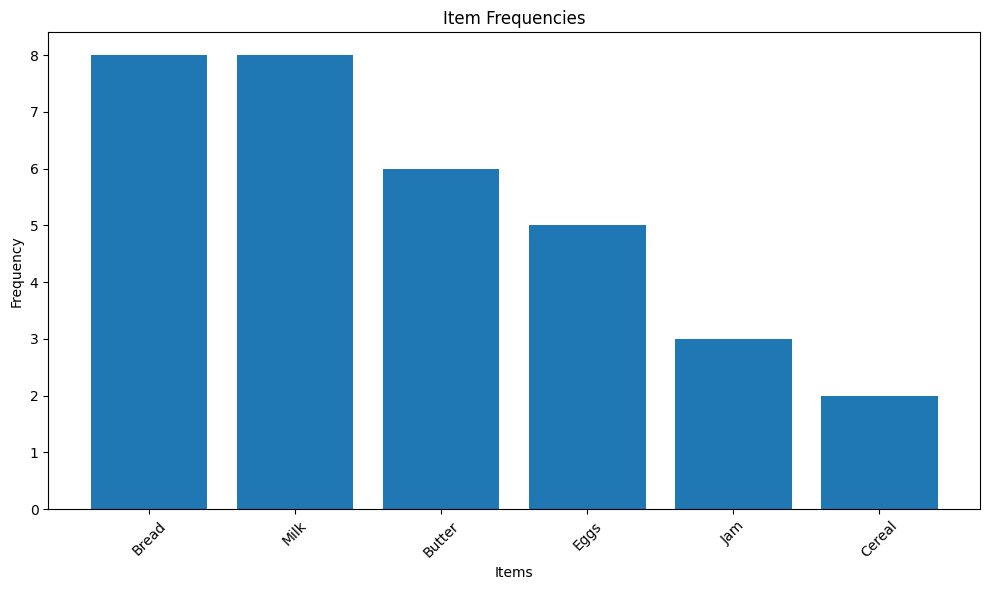

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

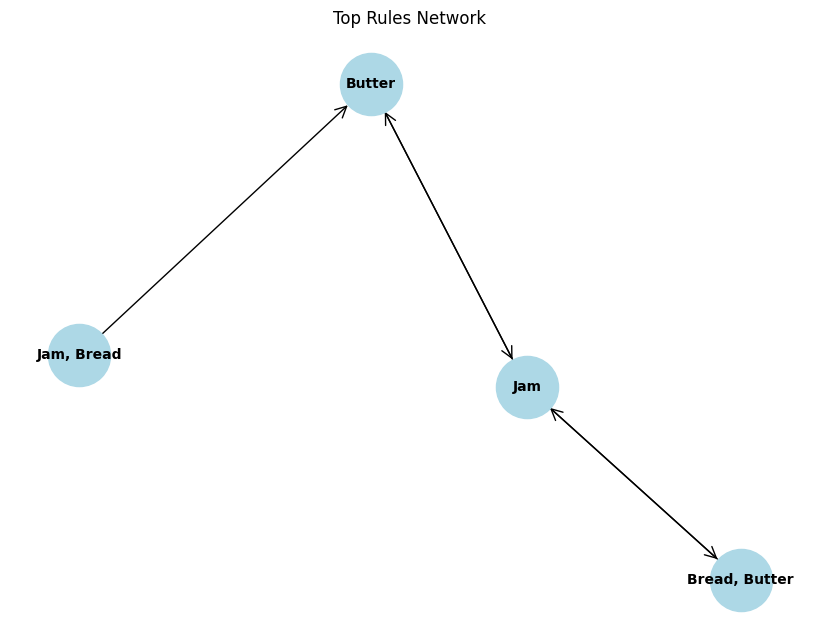

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


BUSINESS INTERPRETATION

What the rules mean:
• If a customer buys [item A], they are likely to also buy [item B]
• Lift > 1 means items are positively associated
• Confidence shows how often the rule holds true

Key Findings:
• Strongest association: Jam → Butter
  (Lift: 1.67)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [15]:
top_conf = rules.nlargest(5, 'confidence')
for i, (idx, row) in enumerate(top_conf.iterrows(), 1):
    ante = ', '.join(list(row['antecedents']))
    cons = ', '.join(list(row['consequents']))
    print(f"{i}. {ante} → {cons}")
    print(f"   Support: {row['support']:.2f}, Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}")

# Simple visualization
plt.figure(figsize=(10, 6))
plt.bar(range(len(item_freq)), item_freq.values)
plt.xticks(range(len(item_freq)), item_freq.index, rotation=45)
plt.title('Item Frequencies')
plt.xlabel('Items')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Simple network graph
if len(rules) > 0:
    plt.figure(figsize=(8, 6))
    G = nx.DiGraph()

    # Add top 5 rules to graph
    for idx, row in top_lift.iterrows():
        ante = ', '.join(list(row['antecedents']))
        cons = ', '.join(list(row['consequents']))
        G.add_edge(ante, cons, weight=row['lift'])
        pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue',
            node_size=2000, font_size=10, font_weight='bold',
            arrows=True, arrowstyle='->', arrowsize=20)
    plt.title('Top Rules Network')
    plt.show()

# Business Interpretation
print("\n" + "="*60)
print("BUSINESS INTERPRETATION")
print("="*60)

print("\nWhat the rules mean:")
print("• If a customer buys [item A], they are likely to also buy [item B]")
print("• Lift > 1 means items are positively associated")
print("• Confidence shows how often the rule holds true")
print("\nKey Findings:")
if len(rules) > 0:
    best_rule = rules.nlargest(1, 'lift').iloc[0]
    ante = ', '.join(list(best_rule['antecedents']))
    cons = ', '.join(list(best_rule['consequents']))
    print(f"• Strongest association: {ante} → {cons}")
    print(f"  (Lift: {best_rule['lift']:.2f})")

In [16]:
print("\nMarketing Suggestions:")
print("1. Store Layout: Place associated items near each other")
print("2. Promotions: Offer discounts on pairs that are frequently bought together")
print("3. Cross-selling: Train staff to suggest complementary items")
print("4. Product placement: Create themed displays (e.g., breakfast section)")

# Save results
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_csv('simple_rules.csv', index=False)
print("\nResults saved to 'simple_rules.csv'")


Marketing Suggestions:
1. Store Layout: Place associated items near each other
2. Promotions: Offer discounts on pairs that are frequently bought together
3. Cross-selling: Train staff to suggest complementary items
4. Product placement: Create themed displays (e.g., breakfast section)

Results saved to 'simple_rules.csv'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag